# Paramétrage de l'environnement de travail et import des packages

In [1]:
import sys
from pathlib import Path

In [112]:
ROOT = Path.cwd().parents[0]

RAW_DATA = ROOT / "01_data" / "01_raw"
PROCESSED_DATA = ROOT / "01_data" / "02_processed"

%load_ext autoreload
%autoreload 2
sys.path.append(str(ROOT / "03_fonctions"))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [89]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from fonctions_perso.data_visualization import smart_countplot, plot_kde_multivariables_grid, plot_boxplots_grid, plot_countplots_bivarie_grid

# La base de données

In [8]:
data_fraud = pd.read_parquet(PROCESSED_DATA / "data_fraud_processed.parquet")

data_fraud = data_fraud[data_fraud["annee_transaction"]==2020]

**Informations globales**

In [9]:
data_fraud.info()

<class 'pandas.core.frame.DataFrame'>
Index: 558005 entries, 0 to 1295733
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   nom_magasin                558005 non-null  object 
 1   type_magasin               558005 non-null  object 
 2   montant_transaction        558005 non-null  float64
 3   ville_client               558005 non-null  object 
 4   etat_client                558005 non-null  object 
 5   latitude_domicile_client   558005 non-null  float64
 6   longitude_domicile_client  558005 non-null  float64
 7   population_ville_client    558005 non-null  int64  
 8   profession_client          558005 non-null  object 
 9   numero_transaction         558005 non-null  object 
 10  latitude_magasin           558005 non-null  float64
 11  longitude_magasin          558005 non-null  float64
 12  target                     558005 non-null  int64  
 13  annee_transaction          558005

**Statistiques descriptives**

In [10]:
data_fraud.describe()

,montant_transaction,latitude_domicile_client,longitude_domicile_client,population_ville_client,latitude_magasin,longitude_magasin,target,annee_transaction,heure_transaction,distance_domicile_magasin,age_client
count,558005.000000,558005.000000,558005.000000,5.580050e+05,558005.000000,558005.000000,558005.000000,558005.0,558005.000000,558005.000000,558005.000000
mean,71.295363,38.543625,-90.231778,8.828106e+04,38.543123,-90.231859,0.007941,2020.0,12.814021,76.103245,46.650503
std,161.108366,5.060867,13.723244,3.007759e+05,5.095446,13.734584,0.088757,0.0,6.825791,29.115613,17.423984
min,1.000000,20.027100,-165.672300,2.300000e+01,19.027422,-166.671575,0.000000,2020.0,0.000000,0.123883,15.000000
25%,9.660000,34.668900,-96.798000,7.410000e+02,34.755493,-96.904843,0.000000,2020.0,7.000000,55.287487,33.000000
50%,47.460000,39.371600,-87.476900,2.408000e+03,39.376032,-87.444854,0.000000,2020.0,14.000000,78.177847,45.000000
75%,83.460000,41.894800,-80.175200,1.968500e+04,41.954690,-80.265870,0.000000,2020.0,19.000000,98.517146,58.000000
max,22768.110000,65.689900,-67.950300,2.906700e+06,66.679297,-66.952026,1.000000,2020.0,23.000000,150.922713,96.000000


**Aperçu rapide des données**

In [11]:
data_fraud.head()

,nom_magasin,type_magasin,montant_transaction,ville_client,etat_client,latitude_domicile_client,longitude_domicile_client,population_ville_client,profession_client,numero_transaction,latitude_magasin,longitude_magasin,target,annee_transaction,mois_transaction,jour_transaction,heure_transaction,distance_domicile_magasin,age_client
0,Kirlin and Sons,personal_care,2.86,Columbia,SC,33.9659,-80.9355,333497,Mechanical engineer,2da90c7d74bd46a0caf3777415b3ebd3,33.986391,-81.200714,0,2020,June,Sunday,12,24.561496,52
1,Sporer-Keebler,personal_care,29.84,Altonah,UT,40.3207,-110.4360,302,"Sales professional, IT",324cc204407e99f51b0d6ca0055005e7,39.450498,-109.960431,0,2020,June,Sunday,12,104.925237,30
2,"Swaniawski, Nitzsche and Welch",health_fitness,41.28,Bellmore,NY,40.6729,-73.5365,34496,"Librarian, public",c81755dbbbea9d5c77f094348a7579be,40.495810,-74.196111,0,2020,June,Sunday,12,59.080159,50
3,Haley Group,misc_pos,60.05,Titusville,FL,28.5697,-80.8191,54767,Set designer,2159175b9efe66dc301f149d3d5abf8c,28.812398,-80.883061,0,2020,June,Sunday,12,27.698606,33
4,Johnston-Casper,travel,3.19,Falmouth,MI,44.2529,-85.0170,1126,Furniture designer,57ff021bd3f328f8738bb535c302a31b,44.959148,-85.884734,0,2020,June,Sunday,12,104.335250,65


# Analyse explaratoire des données 

In [62]:
premier_semestre = [
    "January","February","March",
    "April","May","June"
]

second_semestre = [
    "July","August","September",
    "October","November","December"
]

data_fraud_S1 = data_fraud[data_fraud["mois_transaction"].isin(premier_semestre)]
data_fraud_S2 = data_fraud[data_fraud["mois_transaction"].isin(second_semestre)]

In [78]:
# Répartition des mois et répartition du nombre de fraudes selon le semestre
print("PREMIER SEMESTRE")
print(data_fraud["mois_transaction"][data_fraud["mois_transaction"].isin(premier_semestre)].value_counts())
print("="*30)
print(data_fraud["target"][data_fraud["mois_transaction"].isin(premier_semestre)].value_counts())
print("="*30)
print("="*30)
print("SECOND SEMESTRE")
print(data_fraud["mois_transaction"][data_fraud["mois_transaction"].isin(second_semestre)].value_counts())
print("="*30)
print(data_fraud["target"][data_fraud["mois_transaction"].isin(second_semestre)].value_counts())

PREMIER SEMESTRE
mois_transaction
June        30392
May           527
March         444
January       343
February      336
April         302
Name: count, dtype: int64
target
0    29925
1     2419
Name: count, dtype: int64
SECOND SEMESTRE
mois_transaction
December     139538
August        88759
July          85848
November      72635
September     69533
October       69348
Name: count, dtype: int64
target
0    523649
1      2012
Name: count, dtype: int64


### Analyse univariée

**Analyse de la variable cible**

In [ ]:
print(data_fraud_S1["target"].mean()) # 7% de fraude au premier semestre
print(data_fraud_S2["target"].mean()) # 0,03% de fraude au deuxième semestre

0.07478976007914914
0.0038275618697221213


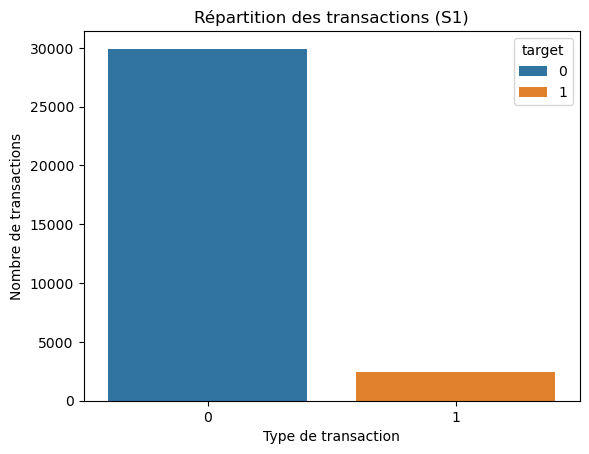

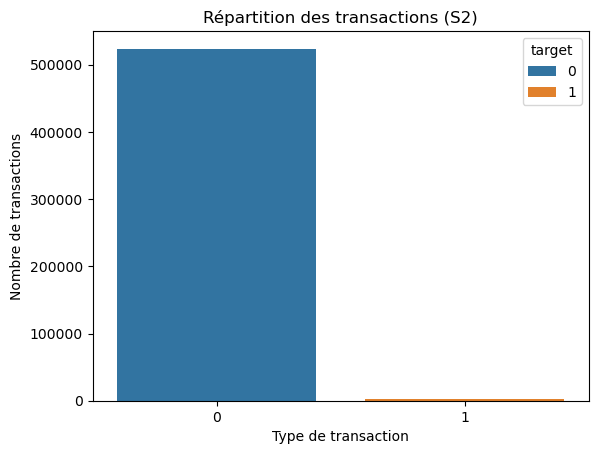

In [66]:
plt.title("Répartition des transactions (S1)")
plt.ylabel("Nombre de transactions")
plt.xlabel("Type de transaction")
sns.countplot(
    data=data_fraud_S1,
    x="target",
    hue="target"
)
plt.show()

plt.title("Répartition des transactions (S2)")
plt.ylabel("Nombre de transactions")
plt.xlabel("Type de transaction")
sns.countplot(
    data=data_fraud_S2,
    x="target",
    hue="target"
)
plt.show()


In [72]:
print("Nombre de transactions non frauduleuses/frauduleuses (S1)")
print(len(data_fraud_S1))
print(data_fraud_S1["target"].value_counts())

print("="*30)

print("Nombre de transactions non frauduleuses/frauduleuses (S2)")
print(len(data_fraud_S2))
print(data_fraud_S2["target"].value_counts())

Nombre de transactions non frauduleuses/frauduleuses (S1)
32344
target
0    29925
1     2419
Name: count, dtype: int64
Nombre de transactions non frauduleuses/frauduleuses (S2)
525661
target
0    523649
1      2012
Name: count, dtype: int64


**Variables catégorielles**

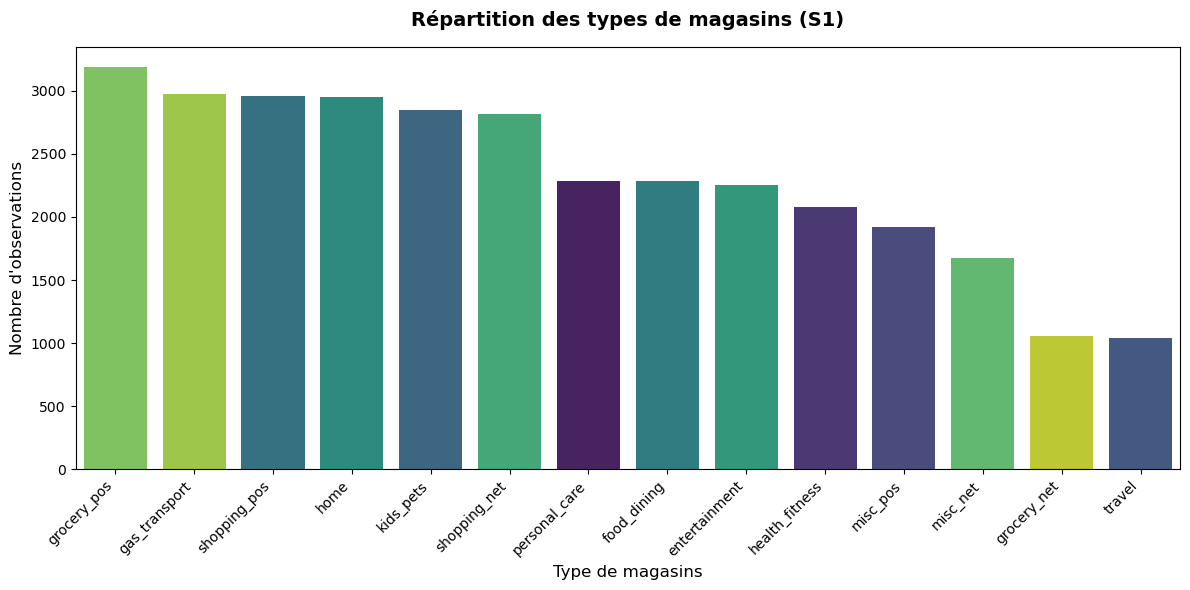

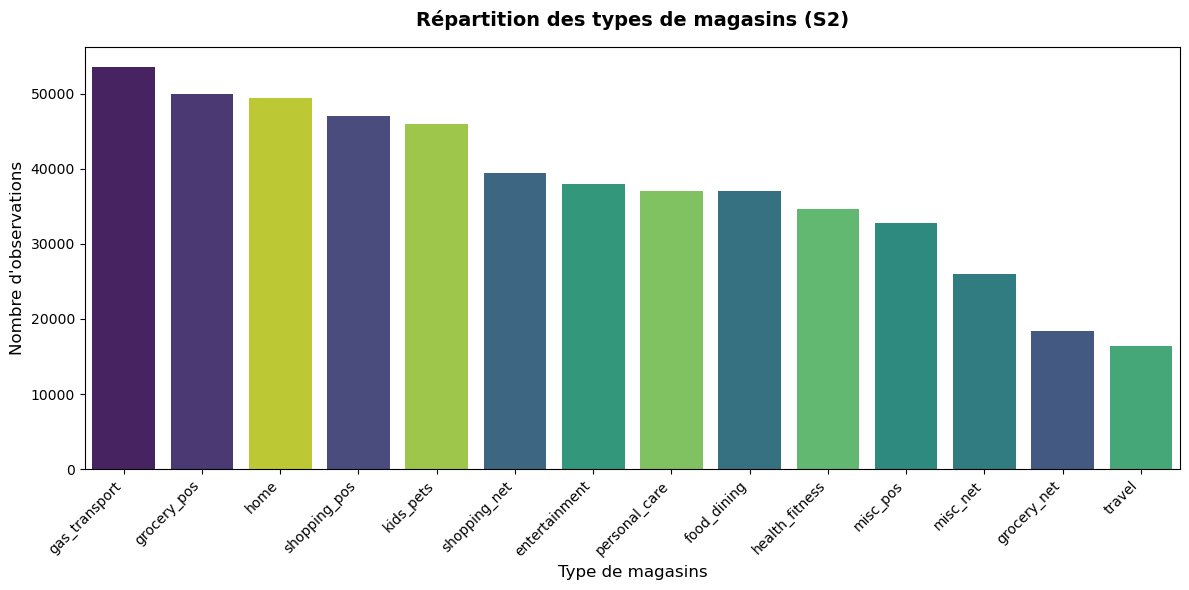

In [ ]:
# Répartition des types de magasins où sont effectuées les transactions selon le semestre

smart_countplot(
    df=data_fraud_S1,
    colonne="type_magasin",
    titre="Répartition des types de magasins (S1)",
    xlabel="Type de magasins",
    ylabel="Nombre d'observations"
)

smart_countplot(
    df=data_fraud_S2,
    colonne="type_magasin",
    titre="Répartition des types de magasins (S2)",
    xlabel="Type de magasins",
    ylabel="Nombre d'observations"
)

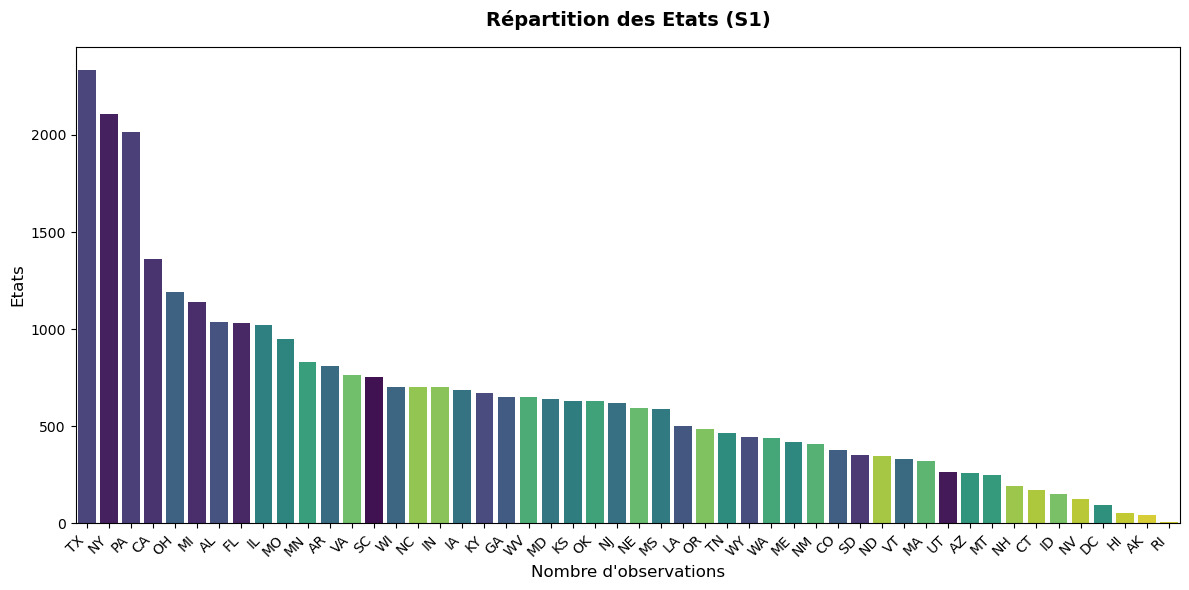

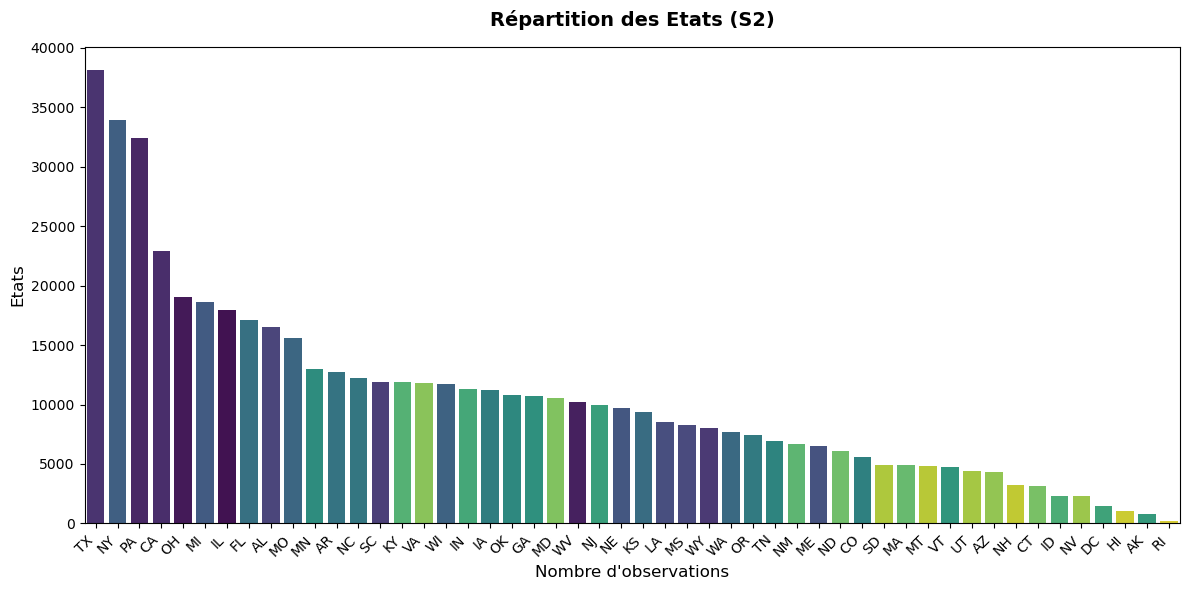

In [ ]:
# Réaprtition des états ou sont effectuées les transactions selon le semestre

smart_countplot(
    df=data_fraud_S1,
    colonne="etat_client",
    titre="Répartition des Etats (S1)",
    xlabel="Nombre d'observations",
    ylabel="Etats"
)


smart_countplot(
    df=data_fraud_S2,
    colonne="etat_client",
    titre="Répartition des Etats (S2)",
    xlabel="Nombre d'observations",
    ylabel="Etats"
)

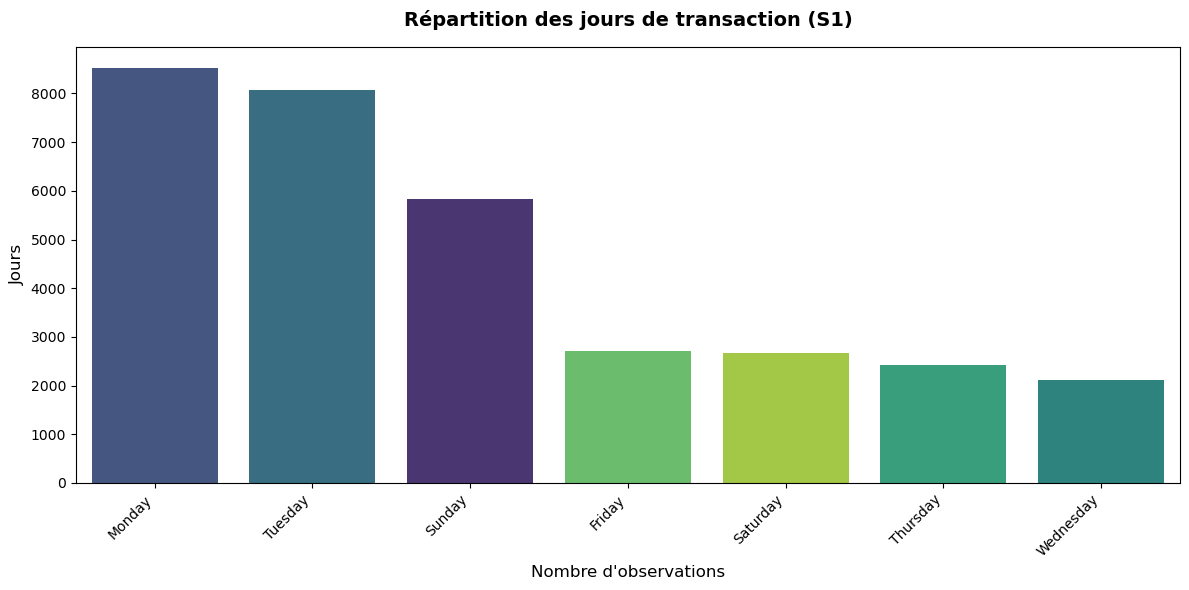

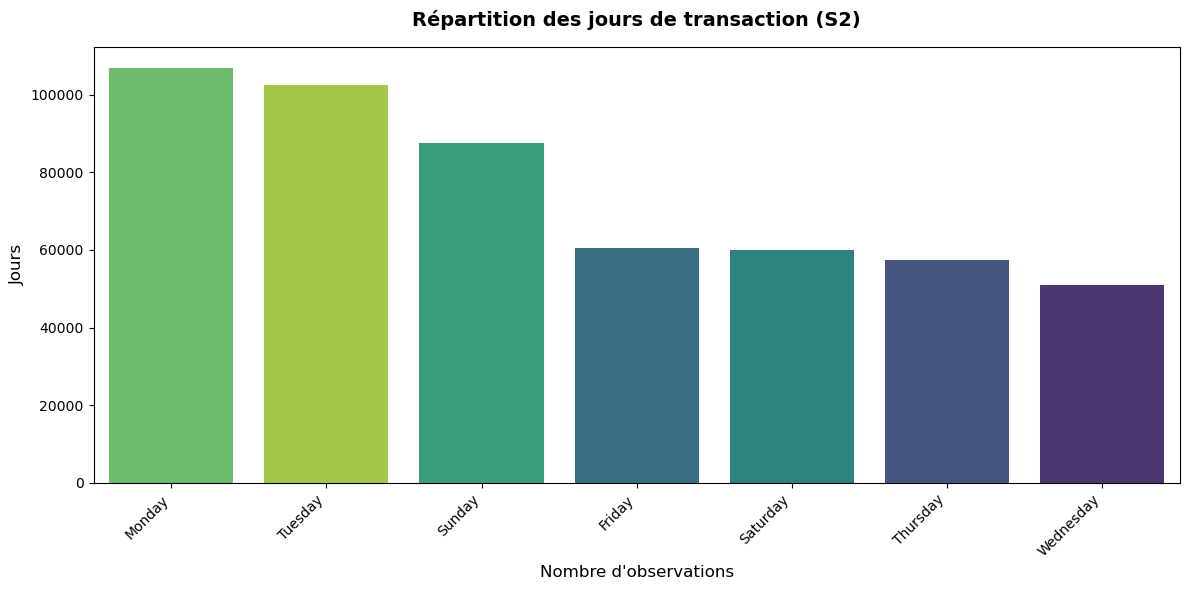

In [ ]:
# Répartition des jours de transaction selon le semestre
smart_countplot(
    df=data_fraud_S1,
    colonne="jour_transaction",
    titre="Répartition des jours de transaction (S1)",
    xlabel="Nombre d'observations",
    ylabel="Jours"
)


smart_countplot(
    df=data_fraud_S2,
    colonne="jour_transaction",
    titre="Répartition des jours de transaction (S2)",
    xlabel="Nombre d'observations",
    ylabel="Jours"
)

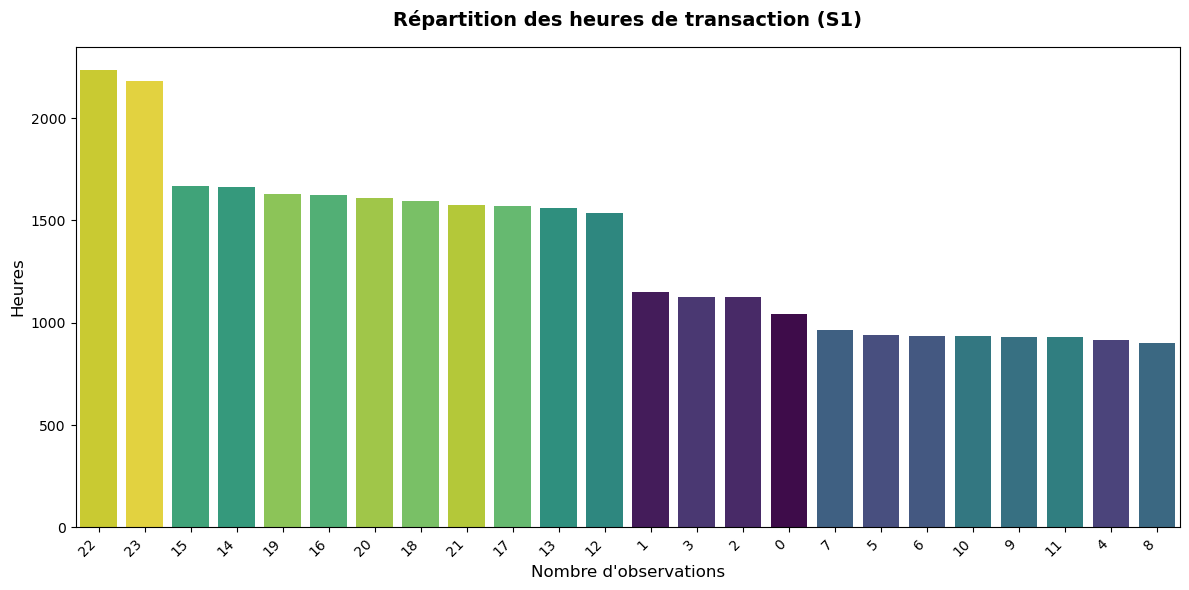

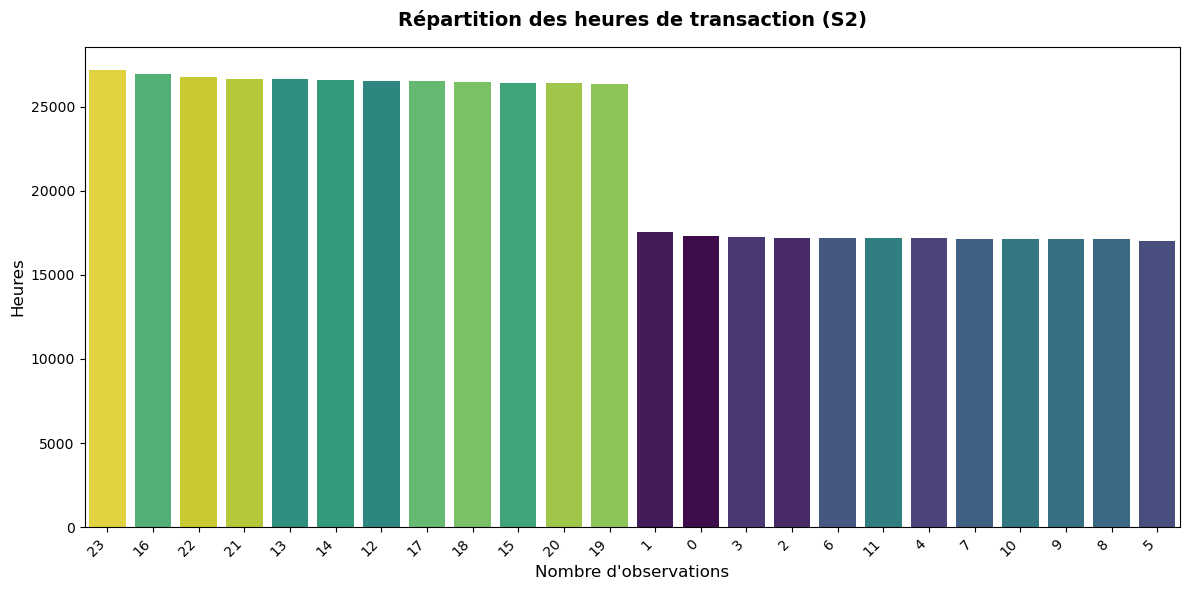

In [ ]:
# Répartition des heures des transactions selon le semestre
smart_countplot(
    df=data_fraud_S1,
    colonne="heure_transaction",
    titre="Répartition des heures de transaction (S1)",
    xlabel="Nombre d'observations",
    ylabel="Heures"
)


smart_countplot(
    df=data_fraud_S2,
    colonne="heure_transaction",
    titre="Répartition des heures de transaction (S2)",
    xlabel="Nombre d'observations",
    ylabel="Heures"
)

**Variables numériques**

In [82]:
variables_numeriques = ["montant_transaction","population_ville_client","age_client"]

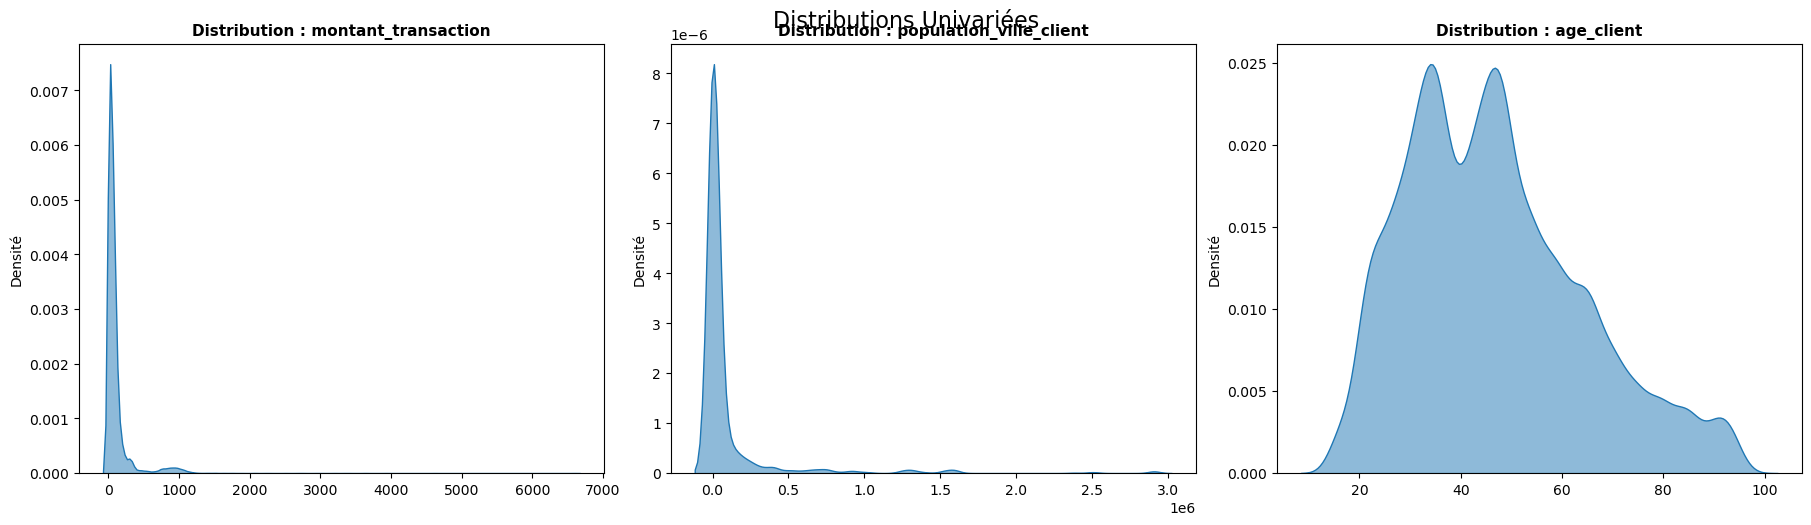

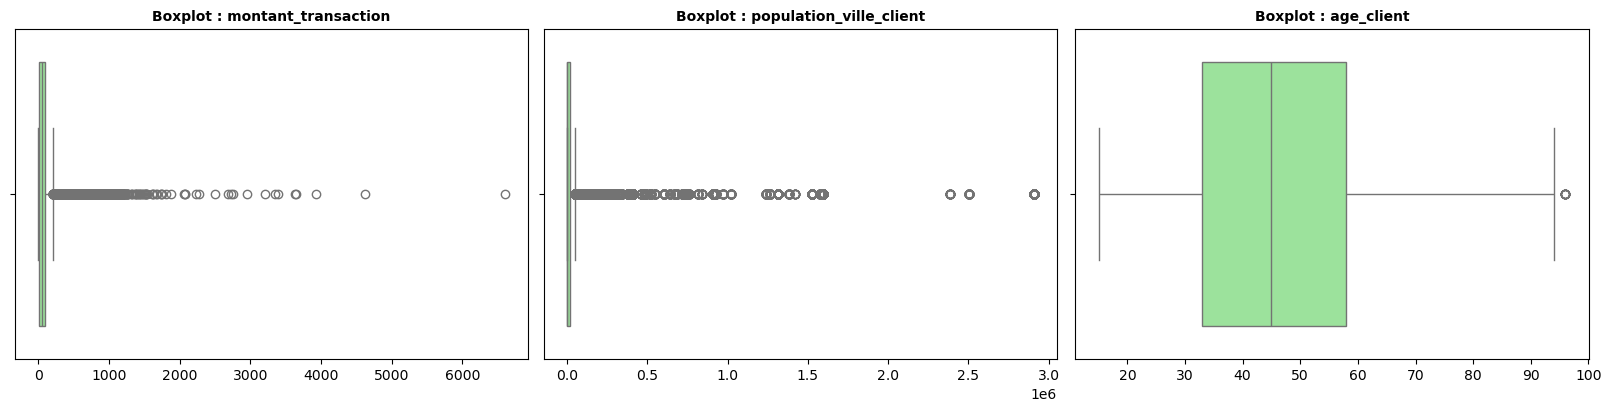

In [87]:
plot_kde_multivariables_grid(
    df=data_fraud_S1,
    features_cols=variables_numeriques
)

plot_boxplots_grid(
    df=data_fraud_S1,
    columns=variables_numeriques
)

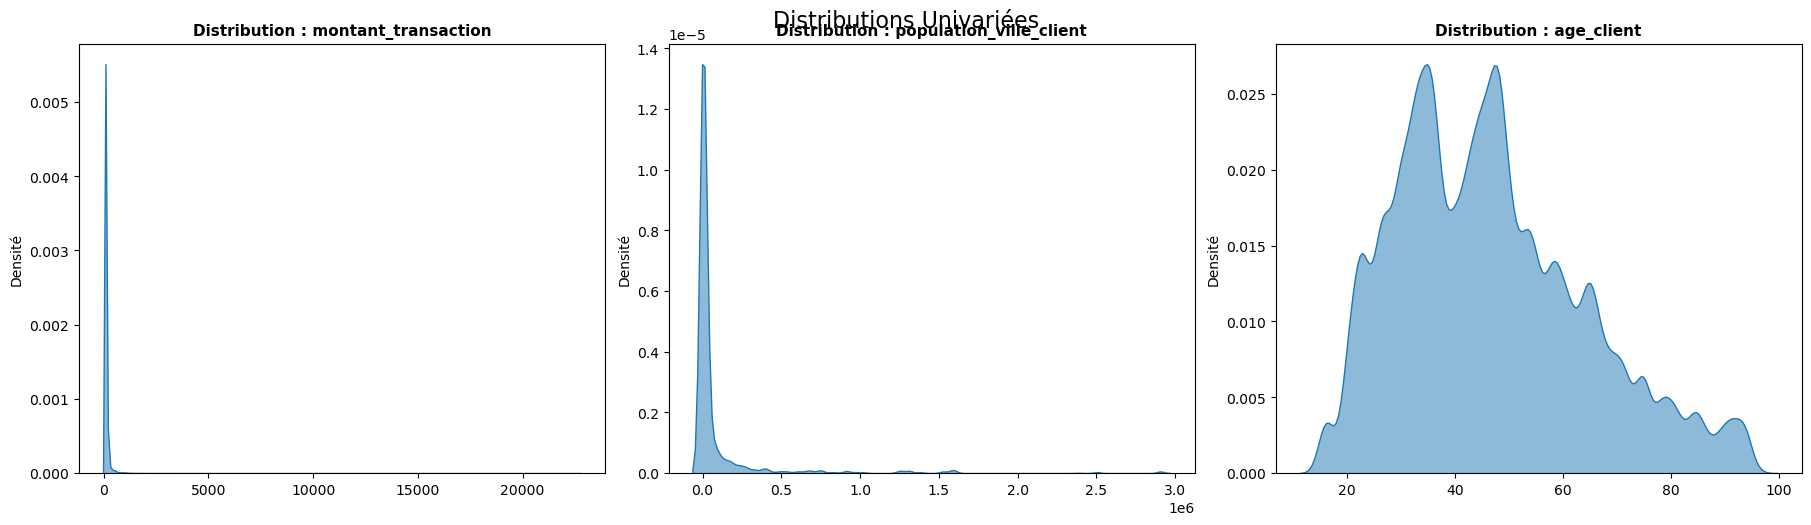

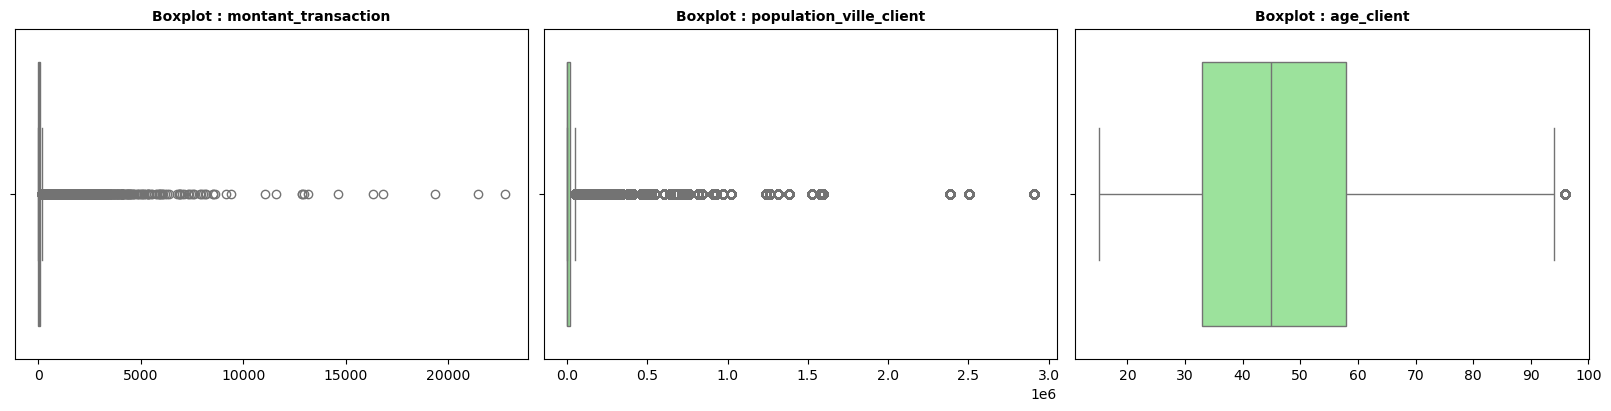

In [88]:
plot_kde_multivariables_grid(
    df=data_fraud_S2,
    features_cols=variables_numeriques
)

plot_boxplots_grid(
    df=data_fraud_S2,
    columns=variables_numeriques
)

### Analyse bivariée

In [91]:
variables_cat = ["type_magasin","etat_client","jour_transaction","heure_transaction"]

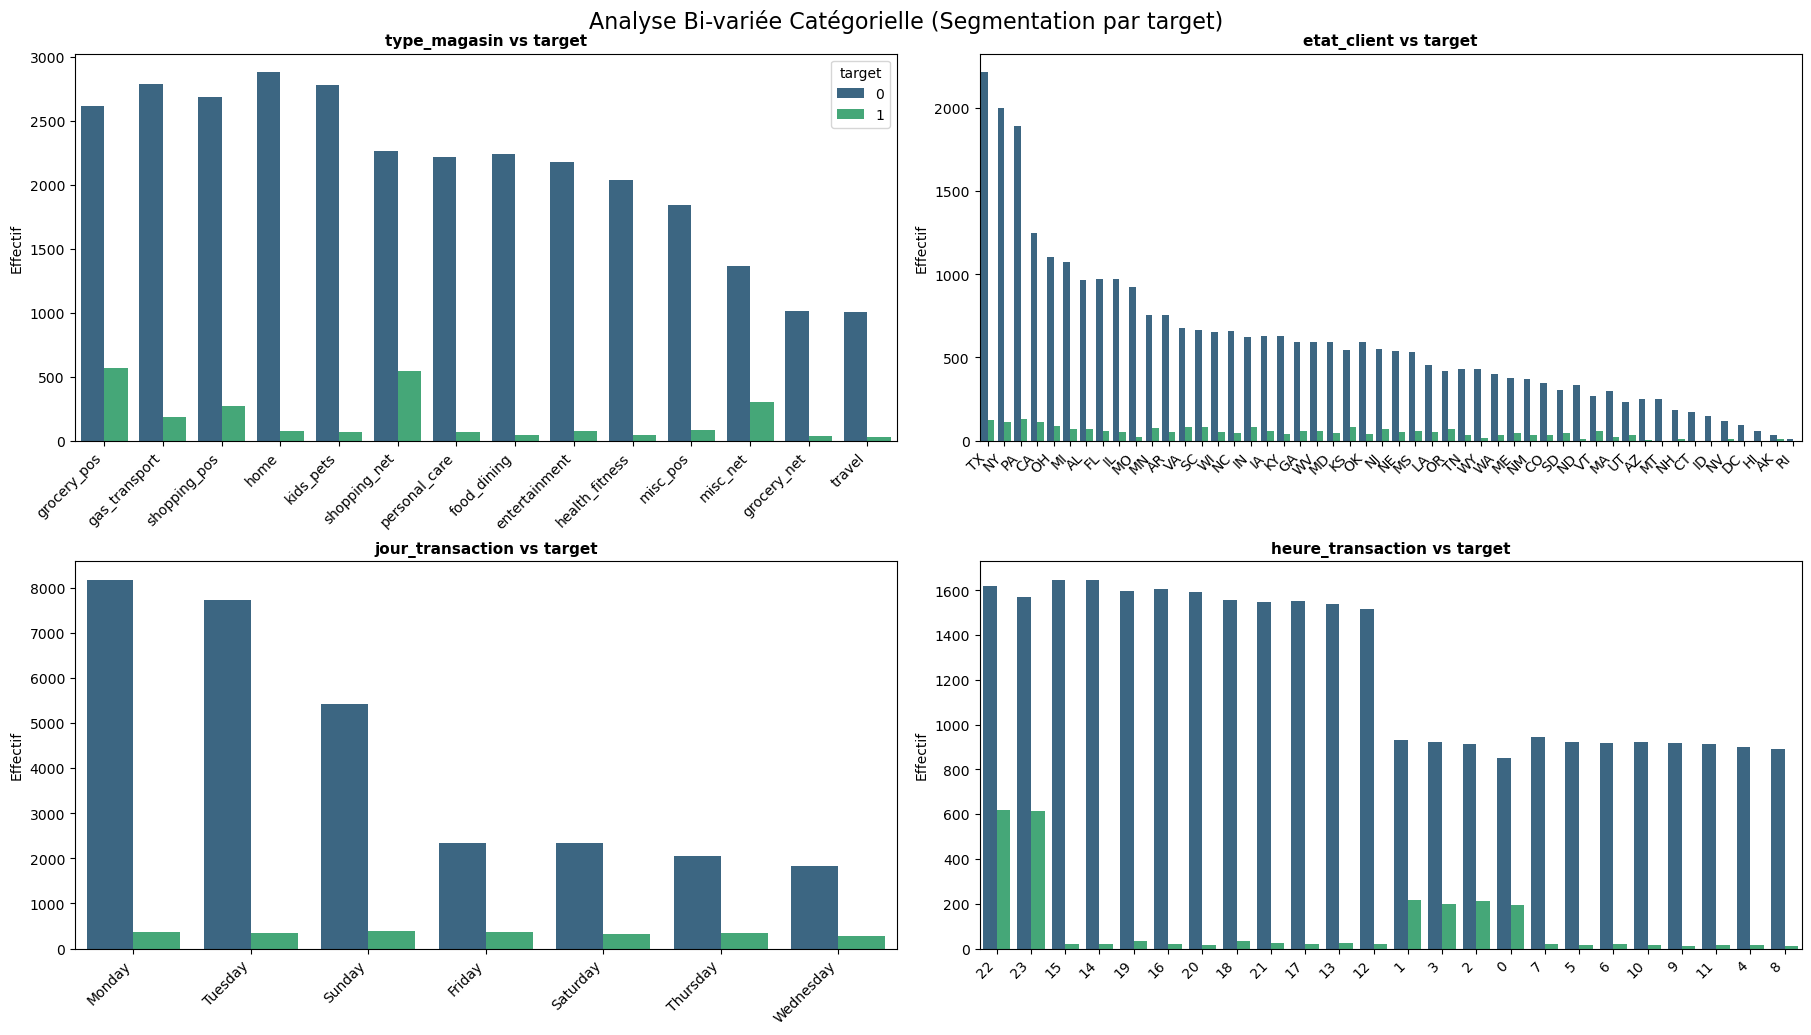

In [96]:
plot_countplots_bivarie_grid(
    data_fraud_S1,
    target_col="target",
    categorical_cols=variables_cat,
    n_cols=2
)

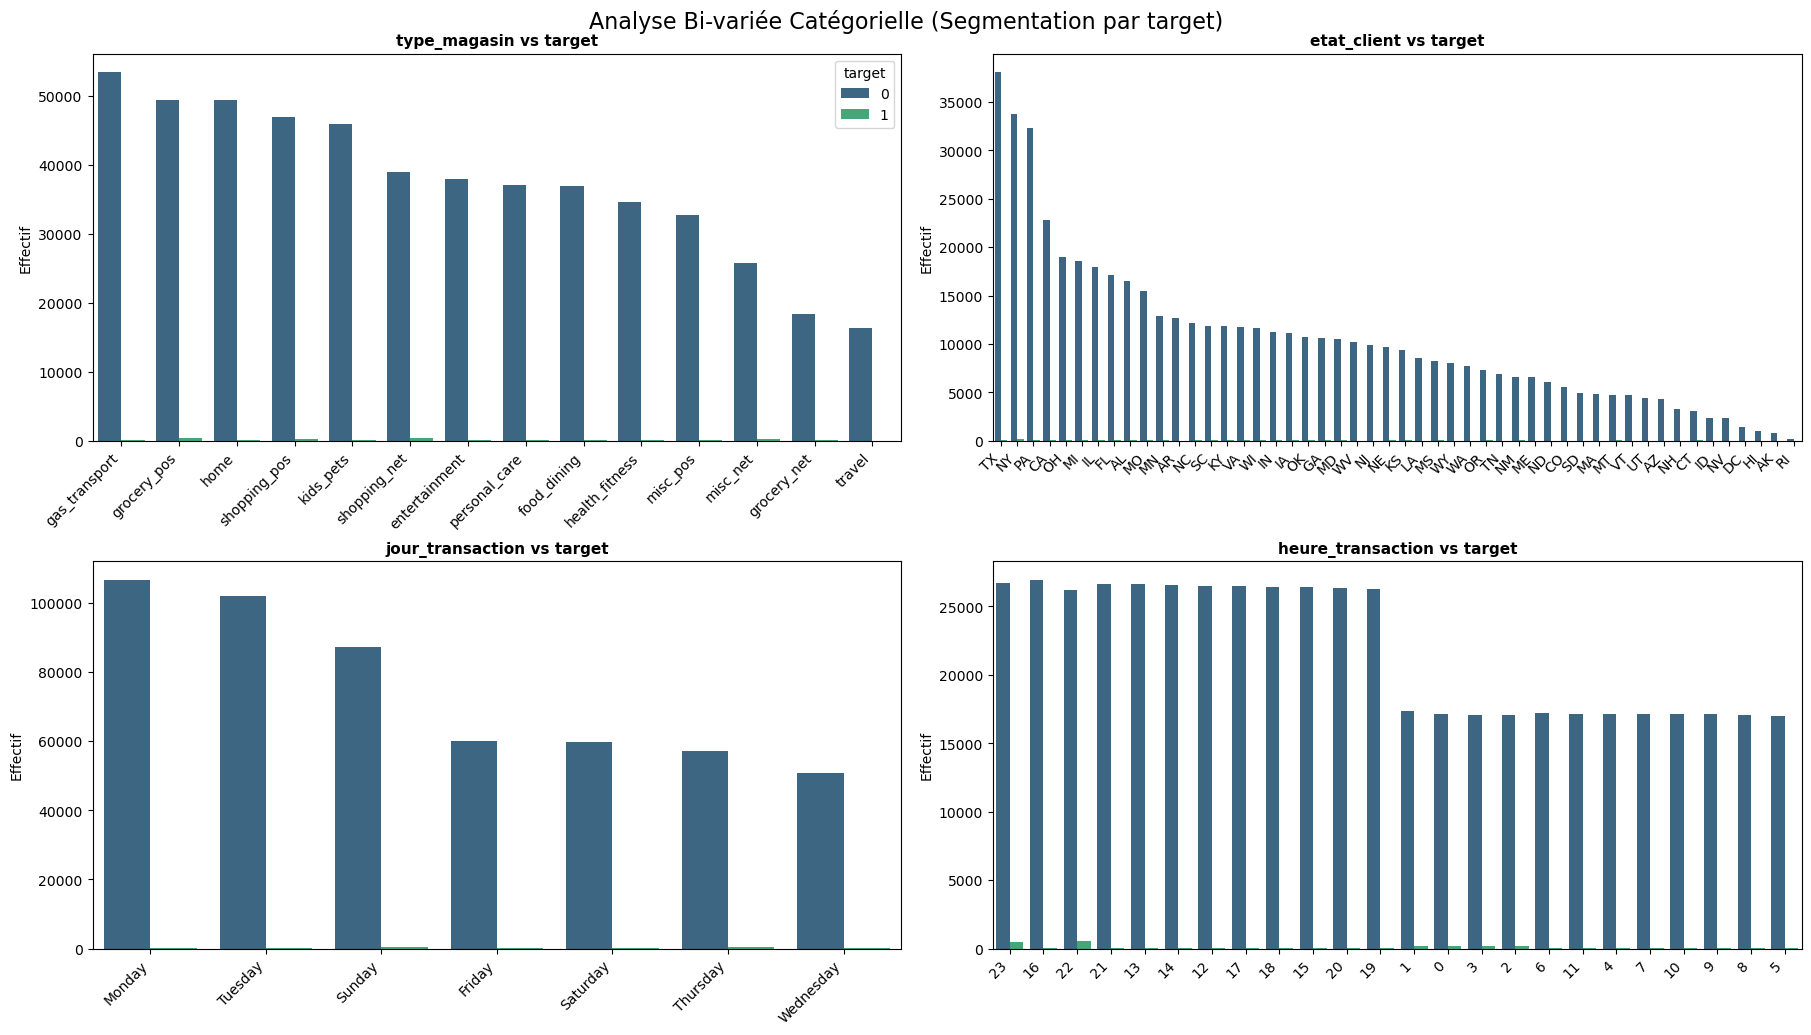

In [97]:
plot_countplots_bivarie_grid(
    data_fraud_S2,
    target_col="target",
    categorical_cols=variables_cat,
    n_cols=2
)

In [98]:
variables_numeriques = ["montant_transaction","population_ville_client","age_client"]

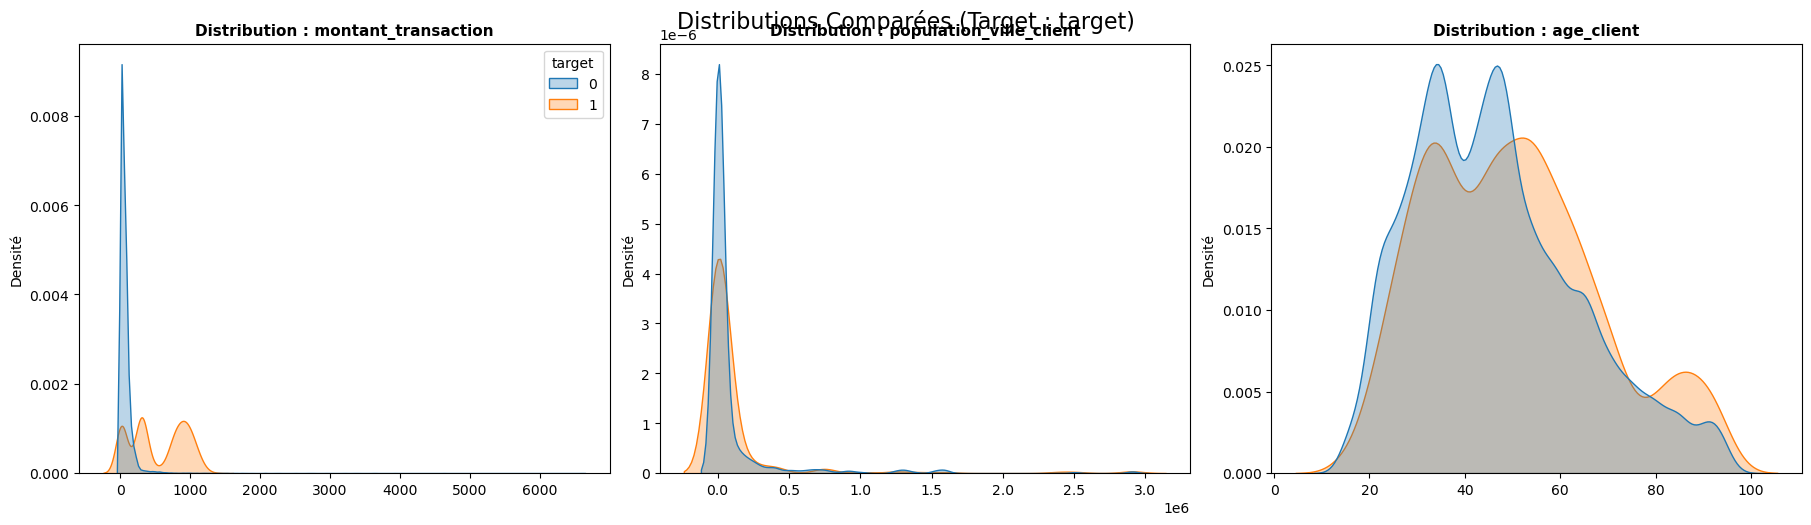

In [99]:
plot_kde_multivariables_grid(
    df=data_fraud_S1,
    features_cols=variables_numeriques,
    target_col="target"
)

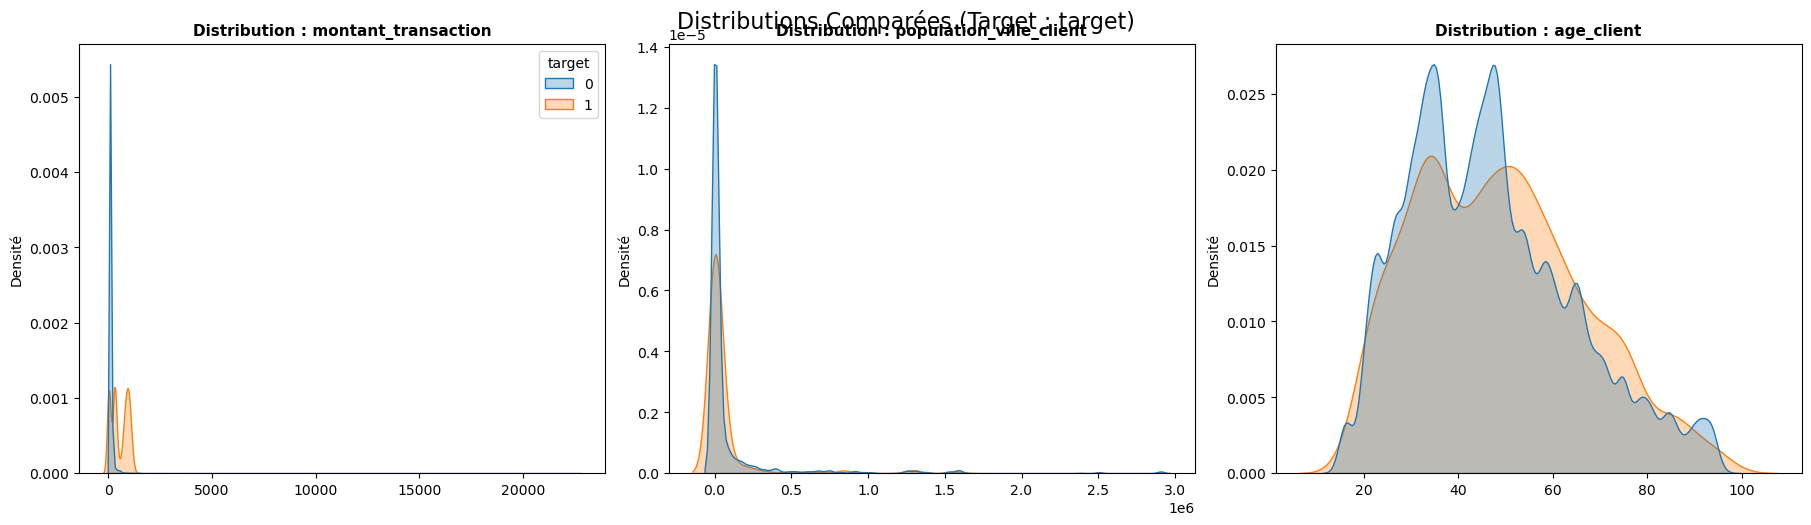

In [100]:
plot_kde_multivariables_grid(
    df=data_fraud_S2,
    features_cols=variables_numeriques,
    target_col="target"
)

# Note explicative du Notebook

Ce notebook vise à comprendre la structure des données et à orienter les choix de modélisation.

### Cadre d’analyse

La suite du projet ne porte que sur les transactions de 2020.  
L’année 2019 contient moins de 5 000 observations, ce qui introduirait un biais temporel.

Le split train / test sera réalisé de manière chronologique :
- **S1 2020** → entraînement  
- **S2 2020** → test  

Les analyses comparent systématiquement ces deux périodes.

---

### 1. Analyse de la variable cible

- Taux global de fraude : **0,07 %** (4 431 fraudes sur 558 005 transactions)
- S1 : 32 344 transactions | ~7 % de fraude  
- S2 : 525 661 transactions | ~0,03 % de fraude  

On observe un fort déséquilibre entre les semestres, à la fois en volume et en taux de fraude.  
Le deuxième semestre concentre la majorité des transactions mais avec un taux beaucoup plus faible.

---

### 2. Analyse des variables catégorielles

**type_magasin**  
14 modalités, structure stable entre S1 et S2.

**etat_client**  
50 modalités.  
Les modalités rares seront regroupées en « autre » afin de limiter la sparsité.

**mois_transaction**  
Déséquilibre marqué du nombre de transactions entre les mois, ce qui reflète le déséquilibre S1/S2.

**jour_transaction**  
Structure similaire sur les deux semestres.

**heure_transaction**  
Structure similaire également, pas de rupture visible entre S1 et S2.

Globalement, pas de changement structurel majeur entre les semestres, hormis le volume et le taux de fraude.

---

### 3. Analyse des variables continues

**montant_transaction**  
Distribution comparable entre S1 et S2.  
Présence de valeurs extrêmes (non bloquantes dans le cadre d’un modèle type XGBoost).

**population_ville_client**  
Distribution similaire sur les deux périodes.  
Quelques valeurs élevées mais cohérentes.

**age_client**  
Distribution stable entre S1 et S2.  
Quelques valeurs extrêmes sans incohérence majeure.

---

### 4. Analyse bivariée avec la cible

#### Variables catégorielles

- **type_magasin** : variable discriminante (grocery_pos, shopping_pos, misc_net, gas_transport ressortent davantage).
- **etat_client** : certains États présentent des taux de fraude plus élevés.
- **jour_transaction** : peu discriminant.
- **heure_transaction** : fortement discriminante (pics autour de 22h, 23h, 0h, 1h, 2h, 3h).

#### Variables continues (densités fraude vs légitime)

- **montant_transaction** : distributions différentes.
- **age_client** : distributions différentes.
- **population_ville_client** : distributions proches, faible pouvoir discriminant.

---

### 5. Décisions pour la modélisation

- Split chronologique S1 (train) / S2 (test).
- Utilisation exclusive des données de 2020.
- Regroupement des modalités rares de `etat_client` en « autre ».
- Exclusion de :
  - `jour_transaction` (peu discriminant),
  - `mois_transaction` (redondant avec le split temporel),
  - `population_ville_client` (faible pouvoir explicatif).

Ce notebook permet donc d’identifier les variables pertinentes et d’éviter d’introduire du bruit ou des fuites d’information avant la phase de modélisation.
